In [1]:
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from IPython.display import Image, display
from scipy import stats

In [2]:
backcbone_and_text_encoders = {
    "google-bert/bert-base-uncased": [
        "h-tomo/unsup-simcse-bert-base-uncased-mean",
        "intfloat/e5-base-v2",
        "thenlper/gte-base",
    ],
    "microsoft/MiniLM-L12-H384-uncased": [
        "sentence-transformers/all-MiniLM-L12-v2",
        "intfloat/e5-small-v2",
        "thenlper/gte-small",
    ],
    "microsoft/mpnet-base": [
        "sentence-transformers/all-mpnet-base-v2",
    ],
    "nomic-ai/nomic-bert-2048": [
        "nomic-ai/nomic-embed-text-v1.5",
    ],
}

In [3]:
dataset_name = "wiki_1000"

records = []
for (
    backbone_model_name,
    text_encoder_model_names,
) in backcbone_and_text_encoders.items():
    for model_name in [backbone_model_name] + text_encoder_model_names:
        socm_avg = pl.read_csv(
            f"../results/socm/{dataset_name}_{model_name.replace('/', '-')}.csv"
        )["socm"].mean()
        mteb_score = pl.read_csv(
            f"../results/mteb/mteb_eng_v2_{model_name.replace('/', '-')}.csv"
        )["mteb_score"][0]
        records.append(
            {"model": model_name, "socm_avg": socm_avg, "mteb_score": mteb_score}
        )

df = pl.DataFrame(records)

In [4]:
result = stats.spearmanr(df["socm_avg"], df["mteb_score"])
print("socm_avg vs mteb_score")
print(f"Spearman ρ = {result.statistic:.3f}")
print(f"p-value = {result.pvalue:.3f}")

socm_avg vs mteb_score
Spearman ρ = -0.678
p-value = 0.015


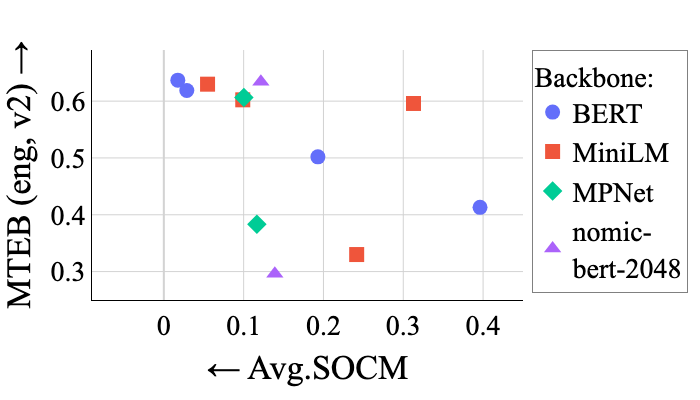

In [5]:
fig = go.Figure()

# (backbone, display_name, marker_symbol)
traces = [
    ("google-bert/bert-base-uncased", "BERT", "circle"),
    ("microsoft/MiniLM-L12-H384-uncased", "MiniLM", "square"),
    ("microsoft/mpnet-base", "MPNet", "diamond"),
    ("nomic-ai/nomic-bert-2048", "nomic-<br>bert-2048", "triangle-up"),
]

# traces
for backbone, name, symbol in traces:
    models = [backbone] + backcbone_and_text_encoders[backbone]
    group = df.filter(pl.col("model").is_in(models))
    fig.add_trace(
        go.Scatter(
            x=group["socm_avg"].to_list(),
            y=group["mteb_score"].to_list(),
            mode="markers",
            name=name,
            marker=dict(symbol=symbol, size=15),
        )
    )

# layout and axes
fig.update_layout(
    width=700,
    height=400,
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font=dict(size=28, family="Times New Roman, Arial"),
    legend=dict(
        title=dict(text="Backbone:", font=dict(size=28, color="black")),
        x=1.02,
        y=1.0,
        font=dict(color="black"),
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(0,0,0,0)",
        bordercolor="gray",
        borderwidth=1,
    ),
    margin=dict(l=80, r=140, t=50, b=100, pad=0),
)

fig.update_xaxes(
    range=[-0.09, 0.45],
    title="← Avg.SOCM",
    title_font=dict(color="black"),
    tickfont=dict(color="black"),
    gridcolor="lightgray",
    zerolinecolor="lightgray",
    showline=True,
    linecolor="black",
)

fig.update_yaxes(
    range=[0.25, 0.69],
    title="MTEB (eng, v2) →",
    title_font=dict(color="black"),
    tickfont=dict(color="black"),
    tickvals=[0.3, 0.4, 0.5, 0.6],
    gridcolor="lightgray",
    zerolinecolor="lightgray",
    showline=True,
    linecolor="black",
)

# save and display
save_path = Path("./figs/mteb_vs_socm.png")
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.write_image(str(save_path), format="png", width=700, height=400)
display(Image(str(save_path)))
# fig.write_image(str(save_path.with_suffix(".pdf")), format="pdf", width=700, height=400)
# fig.show()

In [6]:
records = []
for (
    backbone_model_name,
    text_encoder_model_names,
) in backcbone_and_text_encoders.items():
    for model_name in [backbone_model_name] + text_encoder_model_names:
        ltc_avg = pl.read_csv(
            f"../results/last_token_concentration/{dataset_name}_{model_name.replace('/', '-')}.csv"
        )["sx_over_mu_sq"].mean()
        mteb_score = pl.read_csv(
            f"../results/mteb/mteb_eng_v2_{model_name.replace('/', '-')}.csv"
        )["mteb_score"][0]
        records.append(
            {"model": model_name, "ltc_avg": ltc_avg, "mteb_score": mteb_score}
        )

df_ltc = pl.DataFrame(records)

In [7]:
result = stats.spearmanr(df_ltc["ltc_avg"], df_ltc["mteb_score"])
print("last_token_concentration_avg vs mteb_score")
print(f"Spearman ρ = {result.statistic:.3f}")
print(f"p-value = {result.pvalue:.3f}")

last_token_concentration_avg vs mteb_score
Spearman ρ = -0.622
p-value = 0.031
